# Import Library


In [79]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC

# Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# NLTK imports
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure you have the necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


# Load Dataset

In [52]:
# Membaca dataset
df = pd.read_csv('ulasan_aplikasi.csv')

# Menampilkan 5 baris pertama
display(df.head())


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1ae2b4e0-0c90-4bbe-ac35-8f90f6e2ac1c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi macam apa iniiii,mau daftar aja susah...",1,211,4.12.0,2025-03-08 20:53:19,NaN,NaN,4.12.0
1,5e08c4a6-d3f2-43ba-9a47-9332e1c545a0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa eror terus jaringan nya??? Padahal wifi...,1,333,4.11.2,2025-02-25 07:10:13,Mohon maaf atas ketidaknyamanannya. Terkait ke...,2025-03-07 07:21:36,4.11.2
2,a07a2d9d-d058-4134-a356-607943185238,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk registrasi gagal terus, error setelah di...",1,207,4.12.0,2025-03-08 15:16:34,NaN,NaN,4.12.0
3,806384cb-43fb-4abd-9395-b7e0789153d1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong untuk verifikasi waktu mau daftar akun ...,1,287,4.11.2,2025-02-21 13:00:17,Mohon maaf atas ketidaknyamanannya. Pastikan j...,2025-03-11 04:30:26,4.11.2
4,c61fd4a7-b571-452f-9260-7633c9a51006,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,1. Daftar kontrol deket2 hari gabisa karena er...,1,41,4.11.2,2025-03-07 03:48:53,NaN,NaN,4.11.2


# EDA


In [53]:
# # EDA

# Menampilkan informasi umum dataset
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85500 entries, 0 to 85499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              85500 non-null  object
 1   userName              85500 non-null  object
 2   userImage             85500 non-null  object
 3   content               85500 non-null  object
 4   score                 85500 non-null  int64 
 5   thumbsUpCount         85500 non-null  int64 
 6   reviewCreatedVersion  70887 non-null  object
 7   at                    85500 non-null  object
 8   replyContent          57670 non-null  object
 9   repliedAt             57670 non-null  object
 10  appVersion            70887 non-null  object
dtypes: int64(2), object(9)
memory usage: 7.2+ MB
None


In [54]:
# Menampilkan statistik deskriptif
display(df.describe(include='all'))



,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
count,85500,85500,85500,85500,85500.000000,85500.000000,70887,85500,57670,57670,70887
unique,85500,1,1,83836,NaN,NaN,69,85438,1397,57427,69
top,b3992da0-deac-4b80-a0e1-cdbb5be43e34,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sangat membantu,NaN,NaN,4.9.0,2025-01-08 02:29:50,Hi... Terima kasih atas review dan rating yang...,2024-07-24 07:43:46,4.9.0
freq,1,85500,85500,317,NaN,NaN,7700,2,8769,3,7700
mean,NaN,NaN,NaN,NaN,2.385251,1.871158,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.722925,31.565010,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,5.000000,0.000000,NaN,NaN,NaN,NaN,NaN


In [55]:
# Mengecek missing values
print(df.isnull().sum())



reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion    14613
at                          0
replyContent            27830
repliedAt               27830
appVersion              14613
dtype: int64


In [56]:
# Menampilkan jumlah unik setiap kolom
for col in df.columns:
  print(f"Jumlah nilai unik kolom '{col}': {df[col].nunique()}")


Jumlah nilai unik kolom 'reviewId': 85500
Jumlah nilai unik kolom 'userName': 1
Jumlah nilai unik kolom 'userImage': 1
Jumlah nilai unik kolom 'content': 83836
Jumlah nilai unik kolom 'score': 5
Jumlah nilai unik kolom 'thumbsUpCount': 298
Jumlah nilai unik kolom 'reviewCreatedVersion': 69
Jumlah nilai unik kolom 'at': 85438
Jumlah nilai unik kolom 'replyContent': 1397
Jumlah nilai unik kolom 'repliedAt': 57427
Jumlah nilai unik kolom 'appVersion': 69


In [57]:
# Menampilkan distribusi frekuensi untuk kolom kategorikal
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\nDistribusi frekuensi kolom '{col}':\n{df[col].value_counts()}")




Distribusi frekuensi kolom 'reviewId':
reviewId
b3992da0-deac-4b80-a0e1-cdbb5be43e34    1
1ae2b4e0-0c90-4bbe-ac35-8f90f6e2ac1c    1
5e08c4a6-d3f2-43ba-9a47-9332e1c545a0    1
a07a2d9d-d058-4134-a356-607943185238    1
806384cb-43fb-4abd-9395-b7e0789153d1    1
                                       ..
c06d68b2-bc89-46a5-9c07-95dd9fd9ef5d    1
f0cb6018-11d0-446e-a14e-e41ae806e958    1
5dbde9c2-bb32-4667-9e24-bfb14ed4bc3d    1
25e264ee-2c18-40e7-9f2b-b61cd0d29e87    1
e44f74ec-904a-45f1-861c-988e5af75f6a    1
Name: count, Length: 85500, dtype: int64

Distribusi frekuensi kolom 'userName':
userName
Pengguna Google    85500
Name: count, dtype: int64

Distribusi frekuensi kolom 'userImage':
userImage
https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g    85500
Name: count, dtype: int64

Distribusi frekuensi kolom 'content':
content
Sangat membantu                                                                               

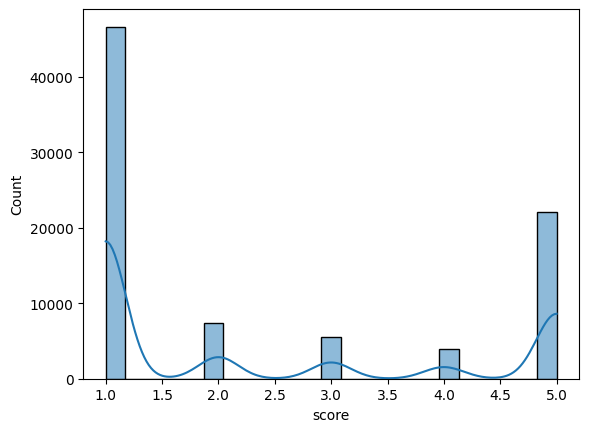

In [58]:


# Visualisasi kolom score

sns.histplot(df['score'], kde=True)
plt.show()


# Preprocessing

**Penangangan Missing value**

*Menangani Missing Value pada reviewCreatedVersion dan appVersion*

In [59]:
df.isnull().sum()


,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,14613
at,0
replyContent,27830
repliedAt,27830


In [60]:
df['reviewCreatedVersion'] = df['reviewCreatedVersion'].fillna(df['reviewCreatedVersion'].mode()[0])
df['appVersion'] = df['appVersion'].fillna(df['appVersion'].mode()[0])


*Menangani Missing Value pada replyContent dan repliedAt*

In [61]:
df['replyContent'] = df['replyContent'].fillna('No reply')
df['repliedAt'] = df['repliedAt'].fillna('No reply')


In [62]:
#mengecek ulang
print(df.isnull().sum())


reviewId                0
userName                0
userImage               0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
replyContent            0
repliedAt               0
appVersion              0
dtype: int64


*menanganin sisanya*

In [63]:
df['content'] = df['content'].fillna('No review provided')
df['score'] = df['score'].fillna(df['score'].mode()[0])
df['thumbsUpCount'] = df['thumbsUpCount'].fillna(0)
df['at'] = df['at'].fillna('Unknown')


In [64]:
#mengecek ulang
print(df.isnull().sum())


reviewId                0
userName                0
userImage               0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
replyContent            0
repliedAt               0
appVersion              0
dtype: int64


# Preprocessing


**Pembersihan data teks**

In [65]:
# Fungsi untuk membersihkan teks
def clean_text(text):
    # Menghapus URL
    text = re.sub(r'http\S+', '', text)
    # Menghapus angka
    text = re.sub(r'\d+', '', text)
    # Menghapus tanda baca
    text = re.sub(r'[^\w\s]', '', text)
    # Menghapus whitespace ekstra
    text = re.sub(r'\s+', ' ', text)
    # Mengubah semua teks menjadi huruf kecil
    text = text.lower()
    return text

# Terapkan pembersihan teks pada kolom 'content'
df['cleaned_content'] = df['content'].apply(clean_text)

# Tampilkan beberapa baris untuk melihat hasil pembersihan
df[['content', 'cleaned_content']].head()


,content,cleaned_content
0,"Aplikasi macam apa iniiii,mau daftar aja susah...",aplikasi macam apa iniiiimau daftar aja susah ...
1,Kenapa eror terus jaringan nya??? Padahal wifi...,kenapa eror terus jaringan nya padahal wifi ja...
2,"Untuk registrasi gagal terus, error setelah di...",untuk registrasi gagal terus error setelah di ...
3,Tolong untuk verifikasi waktu mau daftar akun ...,tolong untuk verifikasi waktu mau daftar akun ...
4,1. Daftar kontrol deket2 hari gabisa karena er...,daftar kontrol deket hari gabisa karena error...


**Tokenisasi**

In [66]:
nltk.download('punkt_tab')

# Fungsi untuk tokenisasi
def tokenize_text(text):
    return word_tokenize(text)

# Terapkan tokenisasi pada kolom 'cleaned_content'
df['tokens'] = df['cleaned_content'].apply(tokenize_text)

# Tampilkan beberapa baris untuk melihat hasil tokenisasi
df[['cleaned_content', 'tokens']].head()


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,cleaned_content,tokens
0,aplikasi macam apa iniiiimau daftar aja susah ...,"[aplikasi, macam, apa, iniiiimau, daftar, aja,..."
1,kenapa eror terus jaringan nya padahal wifi ja...,"[kenapa, eror, terus, jaringan, nya, padahal, ..."
2,untuk registrasi gagal terus error setelah di ...,"[untuk, registrasi, gagal, terus, error, setel..."
3,tolong untuk verifikasi waktu mau daftar akun ...,"[tolong, untuk, verifikasi, waktu, mau, daftar..."
4,daftar kontrol deket hari gabisa karena error...,"[daftar, kontrol, deket, hari, gabisa, karena,..."


**Stopword removal**

In [67]:

nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))  # Kamu bisa menggunakan bahasa yang sesuai

# Fungsi untuk menghapus stopwords
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Terapkan penghapusan stopwords pada kolom 'tokens'
df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)

# Tampilkan beberapa baris untuk melihat hasil stopwords removal
df[['tokens', 'tokens_no_stopwords']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tokens,tokens_no_stopwords
0,"[aplikasi, macam, apa, iniiiimau, daftar, aja,...","[aplikasi, iniiiimau, daftar, aja, susah, bang..."
1,"[kenapa, eror, terus, jaringan, nya, padahal, ...","[eror, jaringan, nya, wifi, jalan, normal, gaa..."
2,"[untuk, registrasi, gagal, terus, error, setel...","[registrasi, gagal, error, refresh, ulang, tol..."
3,"[tolong, untuk, verifikasi, waktu, mau, daftar...","[tolong, verifikasi, daftar, akun, dipermudah,..."
4,"[daftar, kontrol, deket, hari, gabisa, karena,...","[daftar, kontrol, deket, gabisa, error, disuru..."


**Lemmatization**

In [68]:
# Unduh wordnet lemmatizer dan stopwords
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

# Fungsi untuk melakukan lemmatization
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Terapkan lemmatization pada kolom 'tokens_no_stopwords'
df['final_tokens'] = df['tokens_no_stopwords'].apply(lemmatize_tokens)

# Tampilkan beberapa baris untuk melihat hasil lemmatization
df[['tokens_no_stopwords', 'final_tokens']].head()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,tokens_no_stopwords,final_tokens
0,"[aplikasi, iniiiimau, daftar, aja, susah, bang...","[aplikasi, iniiiimau, daftar, aja, susah, bang..."
1,"[eror, jaringan, nya, wifi, jalan, normal, gaa...","[eror, jaringan, nya, wifi, jalan, normal, gaa..."
2,"[registrasi, gagal, error, refresh, ulang, tol...","[registrasi, gagal, error, refresh, ulang, tol..."
3,"[tolong, verifikasi, daftar, akun, dipermudah,...","[tolong, verifikasi, daftar, akun, dipermudah,..."
4,"[daftar, kontrol, deket, gabisa, error, disuru...","[daftar, kontrol, deket, gabisa, error, disuru..."


**Pelabelan data**

In [69]:
def label_sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

df['sentiment'] = df['score'].apply(label_sentiment)


# Mengubah label sentiment menjadi numerik (Positif = 2, Netral = 1, Negatif = 0)
df['sentiment_encoded'] = df['sentiment'].map({'Positif': 2, 'Netral': 1, 'Negatif': 0})

# Tampilkan hasil encoding
df[['sentiment', 'sentiment_encoded']].head()


,sentiment,sentiment_encoded
0,Negatif,0
1,Negatif,0
2,Negatif,0
3,Negatif,0
4,Negatif,0


In [71]:
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,cleaned_content,tokens,tokens_no_stopwords,final_tokens,sentiment,sentiment_encoded
0,1ae2b4e0-0c90-4bbe-ac35-8f90f6e2ac1c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi macam apa iniiii,mau daftar aja susah...",1,211,4.12.0,2025-03-08 20:53:19,No reply,No reply,4.12.0,aplikasi macam apa iniiiimau daftar aja susah ...,"[aplikasi, macam, apa, iniiiimau, daftar, aja,...","[aplikasi, iniiiimau, daftar, aja, susah, bang...","[aplikasi, iniiiimau, daftar, aja, susah, bang...",Negatif,0
1,5e08c4a6-d3f2-43ba-9a47-9332e1c545a0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa eror terus jaringan nya??? Padahal wifi...,1,333,4.11.2,2025-02-25 07:10:13,Mohon maaf atas ketidaknyamanannya. Terkait ke...,2025-03-07 07:21:36,4.11.2,kenapa eror terus jaringan nya padahal wifi ja...,"[kenapa, eror, terus, jaringan, nya, padahal, ...","[eror, jaringan, nya, wifi, jalan, normal, gaa...","[eror, jaringan, nya, wifi, jalan, normal, gaa...",Negatif,0
2,a07a2d9d-d058-4134-a356-607943185238,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk registrasi gagal terus, error setelah di...",1,207,4.12.0,2025-03-08 15:16:34,No reply,No reply,4.12.0,untuk registrasi gagal terus error setelah di ...,"[untuk, registrasi, gagal, terus, error, setel...","[registrasi, gagal, error, refresh, ulang, tol...","[registrasi, gagal, error, refresh, ulang, tol...",Negatif,0
3,806384cb-43fb-4abd-9395-b7e0789153d1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong untuk verifikasi waktu mau daftar akun ...,1,287,4.11.2,2025-02-21 13:00:17,Mohon maaf atas ketidaknyamanannya. Pastikan j...,2025-03-11 04:30:26,4.11.2,tolong untuk verifikasi waktu mau daftar akun ...,"[tolong, untuk, verifikasi, waktu, mau, daftar...","[tolong, verifikasi, daftar, akun, dipermudah,...","[tolong, verifikasi, daftar, akun, dipermudah,...",Negatif,0
4,c61fd4a7-b571-452f-9260-7633c9a51006,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,1. Daftar kontrol deket2 hari gabisa karena er...,1,41,4.11.2,2025-03-07 03:48:53,No reply,No reply,4.11.2,daftar kontrol deket hari gabisa karena error...,"[daftar, kontrol, deket, hari, gabisa, karena,...","[daftar, kontrol, deket, gabisa, error, disuru...","[daftar, kontrol, deket, gabisa, error, disuru...",Negatif,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85495,1e7653d7-5a71-48af-8352-f5c1718437a5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Alhamdulillah mempermudah pindah faskes.. Teri...,5,0,4.7.0,2024-03-02 13:26:51,Hi... Terima kasih atas review dan rating yang...,2024-03-25 04:08:56,4.7.0,alhamdulillah mempermudah pindah faskes terima...,"[alhamdulillah, mempermudah, pindah, faskes, t...","[alhamdulillah, mempermudah, pindah, faskes, t...","[alhamdulillah, mempermudah, pindah, faskes, t...",Positif,2
85496,65f02380-e8a6-49c3-b590-2569d73e9abe,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Knapa saya daptar setiap masukin no tlpn slalu...,2,0,3.6.1,2021-09-15 08:21:52,"""Hai…Mohon maaf atas ketidaknyamanannya\nPasti...",2021-09-15 08:51:48,3.6.1,knapa saya daptar setiap masukin no tlpn slalu...,"[knapa, saya, daptar, setiap, masukin, no, tlp...","[knapa, daptar, masukin, no, tlpn, slalu, klua...","[knapa, daptar, masukin, no, tlpn, slalu, klua...",Negatif,0
85497,75f08354-2801-42ef-b386-40da7c35e856,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa harus tiap bulan min Update nya...,3,0,2.2,2019-12-30 02:35:23,No reply,No reply,2.2,kenapa harus tiap bulan min update nya,"[kenapa, harus, tiap, bulan, min, update, nya]","[min, update, nya]","[min, update, nya]",Netral,1
85498,5f10a0f7-7826-484e-81da-1d4c2d47b859,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mobile jkn Sangat membantu👍,5,0,4.0.1,2022-02-02 09:38:12,Hi... 

# Membangun Model

**LSTM DENGAN TOKENIZER DAN EMBEDDING**

In [70]:
# Memisahkan fitur dan target
X = df['cleaned_content'].apply(lambda x: ' '.join(x))  # Gabungkan tokens menjadi string lagi
y = df['sentiment_encoded']

# Pembagian data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tampilkan ukuran training dan testing set
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Training set size: 68400
Testing set size: 17100


In [72]:
# Tokenization: Ekstraksi fitur
tokenizer = Tokenizer(num_words=10000)  # Menetapkan ukuran maksimal vocabulary
tokenizer.fit_on_texts(X_train)  # Membuat vocabulary dari data training

# Mengonversi teks menjadi urutan token
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding sequences: Menambahkan padding untuk memastikan panjang input seragam
max_length = 100  # Panjang maksimum teks yang diinginkan
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post')


In [80]:
 #Model LSTM
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=128, input_length=max_length))
model.add(LSTM(128, return_sequences=True))  # Menambahkan LSTM lebih banyak
model.add(LSTM(64))  # LSTM tambahan
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))  # Asumsi ada 3 kelas sentimen (Positif, Negatif, Netral)

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_data=(X_test_padded, y_test))


Epoch 1/10
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 426s 393ms/step - accuracy: 0.6443 - loss: 0.7974 - val_accuracy: 0.7604 - val_loss: 0.6576
Epoch 2/10
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 451s 402ms/step - accuracy: 0.7737 - loss: 0.6308 - val_accuracy: 0.8085 - val_loss: 0.5715
Epoch 3/10
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 440s 400ms/step - accuracy: 0.8126 - loss: 0.5554 - val_accuracy: 0.8240 - val_loss: 0.5435
Epoch 4/10
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 442s 399ms/step - accuracy: 0.8322 - loss: 0.5110 - val_accuracy: 0.8380 - val_loss: 0.5010
Epoch 5/10
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 452s 409ms/step - accuracy: 0.8385 - loss: 0.4941 - val_accuracy: 0.8378 - val_loss: 0.4994
Epoch 6/10
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 432s 405ms/step - accuracy: 0.8436 - loss: 0.4779 - val_accuracy: 0.8429 - val_loss: 0.4819
Epoch 7/10
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 439s 402ms/step - accuracy: 0.8516 - loss: 0.4593 - val_accuracy: 0.8483 - val_loss: 0.4661
Epoch 8/10
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 442s 402ms/step - ac

In [81]:
# Evaluate model
train_accuracy = model.evaluate(X_train_padded, y_train)
test_accuracy = model.evaluate(X_test_padded, y_test)

print(f"Train Accuracy: {train_accuracy[1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy[1] * 100:.2f}%")

2138/2138 ━━━━━━━━━━━━━━━━━━━━ 185s 86ms/step - accuracy: 0.8662 - loss: 0.4052
535/535 ━━━━━━━━━━━━━━━━━━━━ 45s 84ms/step - accuracy: 0.8548 - loss: 0.4456
Train Accuracy: 86.47%
Test Accuracy: 85.20%


**SVM DENGAN TF-IDF, DATA SPLIT 80/20**

In [82]:
# Data preprocessing
X = df['cleaned_content']
y = df['sentiment_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train the SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)

# Evaluate the model
y_pred = svm_model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Test Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))

SVM Test Accuracy: 86.33%
              precision    recall  f1-score   support

           0       0.84      0.98      0.91     10848
           1       1.00      0.00      0.00      1108
           2       0.91      0.81      0.86      5144

    accuracy                           0.86     17100
   macro avg       0.92      0.60      0.59     17100
weighted avg       0.88      0.86      0.83     17100



**SVM DENGAN TF-IDF, DATA SPLIT 70/30**

In [93]:


# Data preprocessing
X = df['cleaned_content']
y = df['sentiment_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train the SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)

# Evaluate the model
y_pred = svm_model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Test Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))

SVM Test Accuracy: 86.49%
              precision    recall  f1-score   support

           0       0.84      0.98      0.91     16285
           1       1.00      0.00      0.00      1626
           2       0.92      0.81      0.86      7739

    accuracy                           0.86     25650
   macro avg       0.92      0.60      0.59     25650
weighted avg       0.88      0.86      0.84     25650



# Menyimpan data hasil sentimen ke csv untuk proses inference

In [94]:
df.to_csv('hasil_sentimen.csv', index=False)